# Notebook for evaluating PLRA Verification metrics described in \<DOCUMENT NUMBER\>

In [15]:
# 
# Import dependencies
#

import numpy as np
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18
from astropy import units as u

from lisatools.utils.constants import *
from lisatools.sensitivity import get_sensitivity, A1TDISens
from lisatools.detector import mrdv1, scirdv1, Orbits, DefaultOrbits, LISAModel, EqualArmlengthOrbits
from lisatools.sources import BBHCalculationController, GBCalculationController, EMRICalculationController
from lisatools.sources.emri import EMRITDIWaveform
from lisatools.sources.bbh import BBHSNRWaveform
from lisatools.sources.gb import GBAETWaveform

from eryn.prior import uniform_dist, ProbDistContainer
from eryn.utils import TransformContainer

In [16]:
# 
# Setup detector model
#

calculators = {}
orbits = EqualArmlengthOrbits()
noise = scirdv1
Tobs = 0.9 * YRSID_SI
dt = 10.0
Nobs = int(Tobs / dt)
Tobs = Nobs * dt


## SPR-1: LISA shall measure the GW amplitude of the known UCB systems AM CVn, SDSS J1908, HP Lib, V803 Cen, J0526+5934, HM Cnc to better than 10%

FOM 1: A table including the input binary parameters, the percent error on the GW amplitude for a 1 year observation as approximated by the information matrix, and the observation time needed to achieve the desired amplitude precision.

FOM 2: A marginalized posterior distribution function in amplitude-inclination for a 1 year observation of AM CVn compared to the information matrix estimate to spot check the estimate.

In [17]:
# information matrix calcuation for the binaries

In [18]:
# mcmc run for AM CVn

## SPR-2: LISA shall conduct a census of UCBs with GW frequency between 5 and 20 mHz complete to S/N>10 after T months.

FOM 1: Using an input population (currently from LDC-2) compute the S/N for each UCB above 5 mHz and tally the number that exceed the detection threshold. Compare that to the total number of input binaries.

FOM 2: CDFs and survival function of match between Global Fit catalog and input population, with the total number from FOM 1 included on the survival function plot to assess how well the prototype pipelines are performing relative to this SPR



In [19]:
# read in LDC-2 population and compute S/N

In [20]:
# read in Global Fit catalog match results

## SPR-3: LISA shall conduct a survey of MBH mergers with individual masses between 5e4 and 1e7 M⊙ complete to DL<60 Gpc (z<6); and masses between 1e7 and 1e8 M⊙ complete to DL<16 Gpc (z<2.3)

FOM 1: CDFs of S/Ns from Monte Carlo simulation of MBHs in different mass/distance bins with lines indicating detection threshold (S/N > 10) and completeness (90%) [TBC]

In [27]:
# 
# Set up Monte Carlo
#

snr_lim = 10.0    # Detection threshold
requirement = 0.9 # Completeness requirement
draws = 1024      # Number of draws in the Monte Carlo
qmin = 0.05       # minimum mass ratio for Monte Carlo


In [22]:
# 
# Setup BBHx waveform generator
#

# for transforms
fill_dict_mbh = {
    "ndim_full": 12,
    "fill_values": np.array([0.0]),
    "fill_inds": np.array([6]),
}

# transforms from pe to waveform generation
parameter_transforms_mbh = {
    0: np.exp,
    4: lambda x: x * 1e9 * PC_SI,
    7: np.arccos,
    9: np.arcsin,
    (0, 1): lambda mT, q: (mT / (1 + q), mT * q / (1 + q))
}

transform_fn_mbh = TransformContainer(
    parameter_transforms=parameter_transforms_mbh,
    fill_dict=fill_dict_mbh,
)

psd_kwargs = dict(
    stochastic_params=(Tobs,),
)

# black hole generator
bbh = BBHSNRWaveform(response_kwargs=dict(TDItag="AET", orbits=orbits, tdi2=False))

calculators["bbh"] = BBHCalculationController(
    bbh, 
    noise,
    psd_kwargs, 
    Tobs / YRSID_SI,
    dt,
    psd=A1TDISens
)


z: 2.3, dL: 18.877546494144855 Gpc
z: 2.3, dL: 18.877546494144855 Gpc
z: 2.3, dL: 18.877546494144855 Gpc
z: 2.3, dL: 18.877546494144855 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc


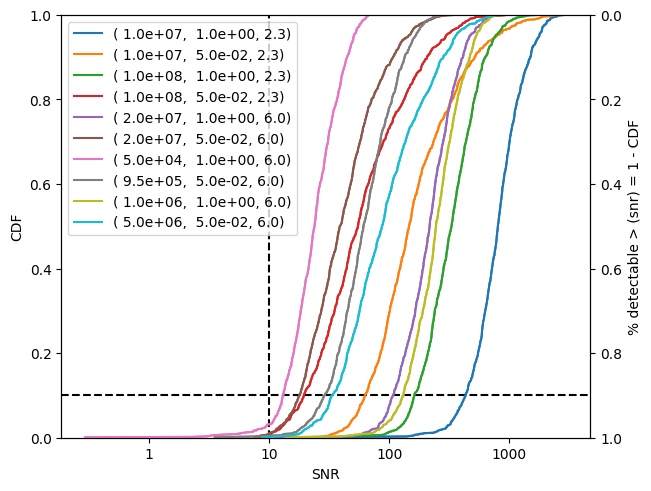

In [29]:
# priors
priors_mbh = ProbDistContainer({
    0: uniform_dist(np.log(1e4), np.log(1e8)),
    1: uniform_dist(0.1, 0.999999999),
    2: uniform_dist(-0.99999999, +0.99999999),
    3: uniform_dist(-0.99999999, +0.99999999),
    4: uniform_dist(0.01, 1000.0),
    5: uniform_dist(0.0, 2 * np.pi),
    6: uniform_dist(-1.0 + 1e-6, 1.0 - 1e-6),
    7: uniform_dist(0.0, 2 * np.pi),
    8: uniform_dist(-1.0 + 1e-6, 1.0 - 1e-6),
    9: uniform_dist(0.0, np.pi),
    10: uniform_dist(0.0, Tobs + 3600.0),
})

# set up cdf figure
plt.close()
fig, ax = plt.subplots(layout='constrained')
ax.axvline(np.log10(snr_lim), color="k", ls="--")
ax.axhline(1 - requirement, color="k", ls="--")
ax2 = ax.twinx()

# the monte carlo
# TODO: This monte carlo is using redshift and converting to DL. We should be using DL and converting to redshift (just for kicks)
injs = [(1e7, 0.99999, 2.3), (1e7, qmin, 2.3), (1e8, 0.99999, 2.3), (1e8, qmin, 2.3), (2e7, 0.99999, 6.0), (2e7, qmin, 6.0), (5e4, 0.99999, 6.0), (9.5e5, qmin, 6.0), (1e6, 0.99999, 6.0), (5e6, qmin, 6.0)]
for i, (M, q, z) in enumerate(injs):
    new_systems = transform_fn_mbh.both_transforms(priors_mbh.rvs(size=draws))

    m1 = M / (1 + q)
    m2 = M * q / (1 + q)
    new_systems[:, 0] = m1
    new_systems[:, 1] = m2
    dL = Planck18.luminosity_distance(z).to(u.m).value
    print(f"z: {z}, dL: {Planck18.luminosity_distance(z).to(u.Gpc)}")
    new_systems[:, 4] = dL
    
    snrs_out = np.zeros(draws)
    for j in range(draws):
        snrs_out[j] = calculators["bbh"].get_snr(*new_systems[j], freqs=np.logspace(-4, 0, 1024))
    
    log10_snrs_out = np.log10(snrs_out.copy())

    cdf = np.arange(1, log10_snrs_out.shape[0] + 1) / log10_snrs_out.shape[0]
    det_frac = 1 - cdf
    x = np.sort(snrs_out)
        
    ax.plot(np.log10(x), cdf, color=f"C{i}", label=f"({M: .01e}, {q: .01e}, {z})")
    ax2.plot(np.log10(x), det_frac, color=f"C{i}", label=f"({M: .01e}, {q: .01e}, {z})")

# format the plot and save
ax2.set_ylim(1.0, 0.0)
ax.set_ylim(0.0, 1.0)
ax2.set_ylabel('% detectable > (snr) = 1 - CDF')
ax.set_xlabel("SNR")
ax.set_xticks(np.log10([1, 10, 100, 1000]))
ax.set_xticklabels([1, 10, 100, 1000])
ax.set_ylabel("CDF")
ax.legend()
fig.savefig("mbh_fom_cdf.png")

## SPR-4: LISA shall conduct a survey of EMRI signals, which is complete for the following parameter ranges: the MBH has rest-frame mass [TBC] in the range 3e5 to 1e6 M⊙; the secondary body has rest-frame mass > 10 M⊙; the final plunge occurs after the first 3 months and before the end of the survey; the orbital eccentricity at plunge is < 0.2; and DL<1 Gpc.

FOM 1: CDFs of S/N from Monte Carlo simulations of EMRIs in different mass bins with lines indicating detection threshold (S/N > 30) and completeness (90%) [TBC]

In [12]:
# monte carlo high mass primary

In [13]:
# monte carlo low mass primary

In [14]:
# form up CDFs

## SPR-5: LISA shall identify and characterize new MBH sources within 36 hours of the GW signal integrated S/N greater than 10 at the constellation.

FOM 1: Benchmarking results from running prototype online search pipelines.

In [16]:
# write a prototype online search pipeline